In [2]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import math

import util

FOLDER = "/Users/brendan/Projects/trails/data/"

# SIZE = 10000
STEPS = 20000

datafiles = [
    # "SVD-zoom|2026-01-14/data.json",
    "SVD|2026-01-09/data.json",
]

In [3]:
dfs = [
    util.load_data(FOLDER + datafile) for datafile in datafiles
]
df = pd.concat(dfs)
util.describe(df)
df.columns

ratios: [100.0]
patch recovery: [0.001 0.0005]
max costs: [2.0 8.0]
boundary conditions: ['PERIODIC' 'SOLID']
num locations: [8 16]
random walker seeds: 64
random locations seeds: 2
patch recovery logic: ['LINEAR']
settings.searchStrategy : ['KANAI_SUZUKI']
steps: 20000
Index(['averageTravelCost', 'averageTravelLength', 'totalImprovement',
       'thresholdImprovement', 'steps', 'paths', 'weightedHeadings',
       'avgHeading', 'avgSquareHeading', 'patches',
       'settings.patchImprovement', 'settings.patchRecovery',
       'settings.maxCost', 'settings.boundaryConditions',
       'settings.numLocations', 'settings.randomSeedWalkers',
       'settings.randomSeedLocations', 'settings.recoveryLogic',
       'settings.improvementLogic', 'settings.searchStrategy', 'ratio'],
      dtype='object')


Index(['averageTravelCost', 'averageTravelLength', 'totalImprovement',
       'thresholdImprovement', 'steps', 'paths', 'weightedHeadings',
       'avgHeading', 'avgSquareHeading', 'patches',
       'settings.patchImprovement', 'settings.patchRecovery',
       'settings.maxCost', 'settings.boundaryConditions',
       'settings.numLocations', 'settings.randomSeedWalkers',
       'settings.randomSeedLocations', 'settings.recoveryLogic',
       'settings.improvementLogic', 'settings.searchStrategy', 'ratio'],
      dtype='object')

In [38]:
# Perform the SVD
_all = df[
    (df["settings.patchRecovery"] == 0.001) &
    # (df["steps"] == steps) &
    (df["settings.numLocations"] == 8) &
    (df["settings.randomSeedLocations"] == 1) &
    (df["settings.boundaryConditions"] == "PERIODIC") &
    (df["settings.maxCost"] == 2.0)
].copy()
_final = _all[_all["steps"] == STEPS]
patches = _final["patches"]
N = len(_final)


num_observations = len(patches)
num_features = len(patches.iloc[0])
# observations as rows, features as columns
A = np.reshape(patches.explode(), (num_observations, num_features)).astype(float)

U, S, Vh = np.linalg.svd(A, full_matrices=False)



# U, S, Vh = util.svd(_all, steps, dynamics=True)

In [39]:
# decompose the patches into their components vs the SVD and add it to
# the full dataframe
DIMENSIONS_TO_SHOW = 4

# map the dimensions back across
for i in range(DIMENSIONS_TO_SHOW):
    _all[f"U{i}"] = _all["patches"].map(lambda p: p @ Vh.T[:, i])



/var/folders/q_/ntb72mmd6jd72ljyc9qyw4100000gn/T/ipykernel_2412/103640794.py:7: RuntimeWarning: divide by zero encountered in matmul
  _all[f"U{i}"] = _all["patches"].map(lambda p: p @ Vh.T[:, i])
/var/folders/q_/ntb72mmd6jd72ljyc9qyw4100000gn/T/ipykernel_2412/103640794.py:7: RuntimeWarning: overflow encountered in matmul
  _all[f"U{i}"] = _all["patches"].map(lambda p: p @ Vh.T[:, i])
/var/folders/q_/ntb72mmd6jd72ljyc9qyw4100000gn/T/ipykernel_2412/103640794.py:7: RuntimeWarning: invalid value encountered in matmul
  _all[f"U{i}"] = _all["patches"].map(lambda p: p @ Vh.T[:, i])
/var/folders/q_/ntb72mmd6jd72ljyc9qyw4100000gn/T/ipykernel_2412/103640794.py:7: RuntimeWarning: divide by zero encountered in matmul
  _all[f"U{i}"] = _all["patches"].map(lambda p: p @ Vh.T[:, i])
/var/folders/q_/ntb72mmd6jd72ljyc9qyw4100000gn/T/ipykernel_2412/103640794.py:7: RuntimeWarning: overflow encountered in matmul
  _all[f"U{i}"] = _all["patches"].map(lambda p: p @ Vh.T[:, i])
/var/folders/q_/ntb72mmd6jd7

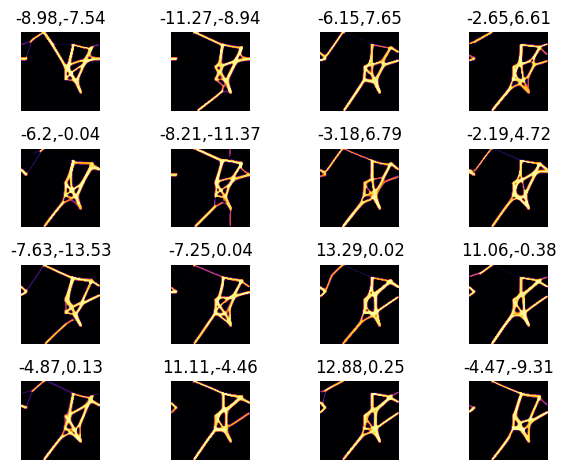

In [41]:
fig, axs = plt.subplots(4, 4)
for i in range(16):
    ax = axs[i // 4][i % 4]
    row = _all[_all["steps"] == STEPS].iloc[i]
    ax.imshow(np.reshape(row["patches"], (100, 100)), cmap="inferno")
    ax.axis('off')
    ax.set_title(f"{round(row['U1'], 2)},{round(row['U2'], 2)}")
plt.tight_layout()
plt.show()

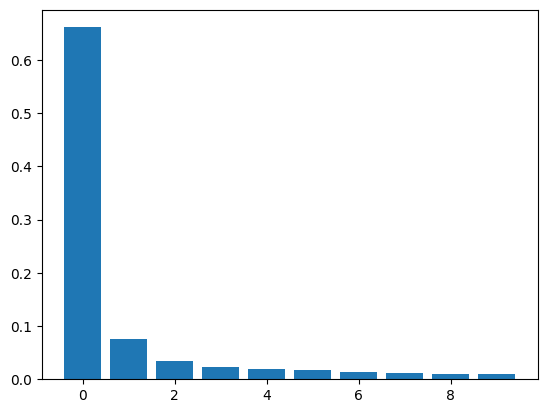

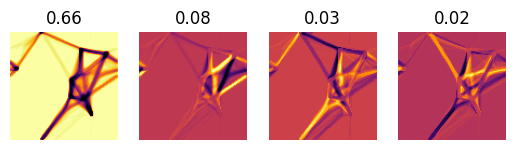

In [42]:
# fig, axs = plt.subplots(2, 1)
s = S**2/sum(S**2)
# axs[0].bar([x for x in range(N)], S[:N]),
plt.bar([x for x in range(10)], s[:10])

# plot the eigen-trails
fig, axs = plt.subplots(1, 4)
for i in range(4):
    ax = axs[i]
    ax.imshow(np.reshape(Vh[i], (100, 100)), cmap="inferno")
    ax.axis('off')
    ax.set_title(f"{round(s[i], 2)}")
plt.show()

In [43]:
# every dot needs to know its final U1, for the lineplot below.
final = _all[_all["steps"] == STEPS]

U1s = {}
for _, r in final.iterrows():
    U1s[r["settings.randomSeedWalkers"]] = r["U1"]

_all["finalU1"] = _all.apply(lambda r: U1s[r["settings.randomSeedWalkers"]], axis=1)

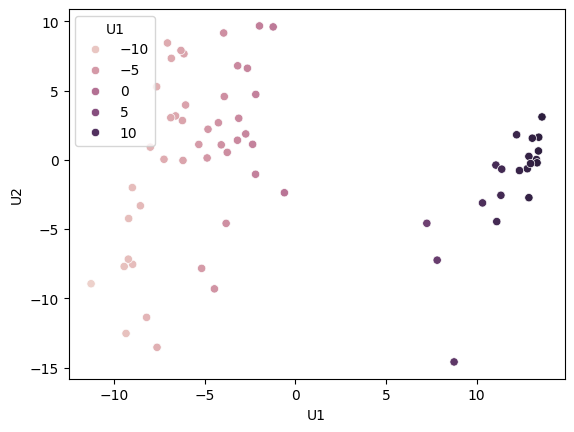

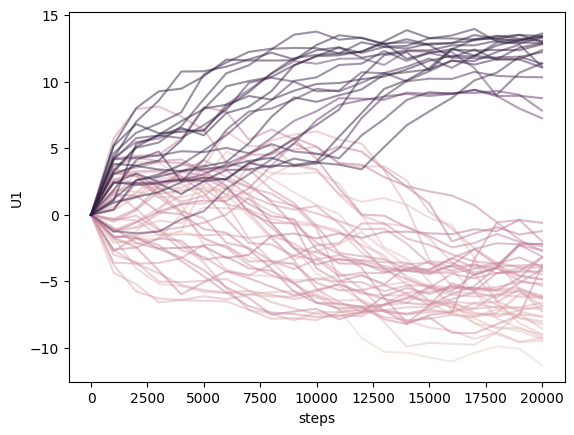

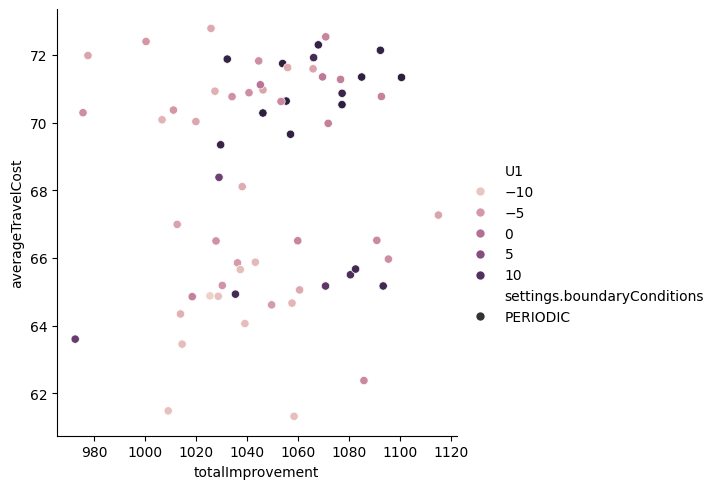

In [44]:
# scatter plot of the first & second components
sns.scatterplot(
    data=_all[_all["steps"] == STEPS],
    x="U1", y="U2", hue="U1",
)
plt.show()
# sns.scatterplot(data=_all[_all["steps"] >= (steps - 10000)], x="U1", y="U2")
# plt.show()

sns.lineplot(
    data=_all[_all["steps"] >= 0],
    x="steps",
    y=f"U1",
    hue="finalU1",
    # hue="settings.randomSeedWalkers",
    style="settings.boundaryConditions",
    alpha=0.5,
    legend=False,
)

# fig, axs = plt.subplots(2, int(DIMENSIONS_TO_SHOW/2))

# for i in range(DIMENSIONS_TO_SHOW):
#     sns.lineplot(data=_all[_all["steps"] >= 0], x="steps", y=f"U{i}", ax=axs[i//2, i%2],
#              hue="settings.randomSeedWalkers", style="settings.boundaryConditions", legend=False)
# plt.show()



sns.relplot(
    data=_all[_all["steps"] == STEPS], y="averageTravelCost",
    hue="U1", x="totalImprovement", style="settings.boundaryConditions",
)
plt.show()

